rundir /Users/tsangkeungchan/Programs/RadHydropy/RadHydropy/example/SodShock1D
--- writing /Users/tsangkeungchan/Programs/RadHydropy/RadHydropy/example/SodShock1D/InitialCondition.hdf5 --- 
--- Get simulation parameters ---
--- 0.2571890354156494 seconds ---
--- Read Initial Condition ---
--- 0.25721216201782227 seconds ---
--- reading /Users/tsangkeungchan/Programs/RadHydropy/RadHydropy/example/SodShock1D/InitialCondition.hdf5 --- 
--- Check parameters ---
--- 0.25986409187316895 seconds ---
--- Start Initial Time ---
--- Set up the Mesh ---
--- 0.25989699363708496 seconds ---
--- Set up the fluid ---
--- 0.2604498863220215 seconds ---
--- Fill up the fluid---
--- 0.2643089294433594 seconds ---
--- Initization finished. Start running ... ---
--- 0.2706780433654785 seconds ---
--- writing /Users/tsangkeungchan/Programs/RadHydropy/RadHydropy/example/SodShock1D/Output_000.hdf5 --- 
--- writing /Users/tsangkeungchan/Programs/RadHydropy/RadHydropy/example/SodShock1D/Output_001.hdf5 --- 
--

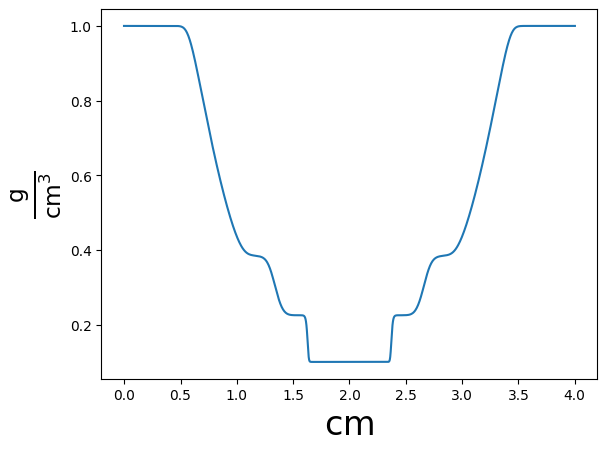

In [1]:
from radhydropy.rsim import Rsim
import unyt
from radhydropy.analysis import rplot1d
import matplotlib.pyplot as plt
import numpy as np
import radhydropy.utils as ru 
import radhydropy.io as rio
#importing the os module
import os
from sodshock_analytic import shocktubecal, shocktubeanalyticgraph

#to get the current working directory
rundir = os.getcwd()
print('rundir',rundir)


runparams = {
    'simname':'SodShock1d',
    'ICfilename':rundir+'/InitialCondition.hdf5',
    'outdir':rundir,
    'outfileprefix':'Output', 
    'savedir':rundir,
    'coordsys':'cartesian', #
    'EOStype':'polytropic', #type of equation of state (EOS): polytropic or isothermal
    'gamma':1.4, # for polytropic, the polytropic index
    'timesim':1.0*unyt.s, # final simulation time
    'outdeltatime':1.0*unyt.s *0.1,
    'ngrid':1000, # number of grid to discretize
    'CFL':0.1, # CFL condition for time-step
    'boundcond':'Periodic',
    'verbose':0, # speak out details?
}

ICparams = {
    'nogrid':1000,
    'coordsys':"cartesian",
    'boxsize':4.0*unyt.cm,
    'time':0.0*unyt.s, 
    'rhoini':1.0 * unyt.g/ unyt.cm**3,
    'uini':0.0 * unyt.km/unyt.s,
    'tempini':1.0 * unyt.g / unyt.cm / unyt.s**2 * (1.28 * unyt.mp) / unyt.kb / (1.0 * unyt.g/unyt.cm**3),
    'muini': 1.0,
    'rhoratio':0.1,
    'tempratio':0.1/0.125
}


class Par():
    def __init__(self) -> None:
        pass

class Mesh():
    def __init__(self) -> None:
        pass

class Fluid():
    def __init__(self) -> None:
        pass

class Simwrap():
    def __init__(self) -> None:
        self.par = Par()
        self.mesh = Mesh()
        self.fluid = Fluid()

        #check the dimension of the initial condition
        ru.CheckParamDimen(ICparams)
        # should be read from parameter files instead
        self.par.nogrid = ICparams['nogrid']
        self.par.coordsys = ICparams['coordsys']
        self.par.boxsize = ICparams['boxsize'] * np.ones(1)
        self.par.time = np.array([0.0]) * ICparams['time']

        # boundary points of the mesh
        # note that we use first (0) and final (nogrid+1) cells as ghost cells
        # to set boundary conditions
        dx = self.par.boxsize[0]/self.par.nogrid

        # generate initial condition
        self.mesh.boundary = np.linspace(-dx,self.par.boxsize[0]+dx,self.par.nogrid+3)
        coordinate = 0.5 * (self.mesh.boundary[1:]+self.mesh.boundary[:-1])
        #print('coordinate',coordinate)

        rho = np.ones(self.par.nogrid+2) * ICparams['rhoini']
        self.fluid.u = np.ones(self.par.nogrid+2) * ICparams['uini']
        # label the region with low density:
        indexlow = np.logical_and(coordinate>0.25*self.par.boxsize[0],coordinate<0.75*self.par.boxsize[0])
        rho[indexlow] *= ICparams['rhoratio']
        self.fluid.rho = rho
        temp = np.ones(self.par.nogrid+2) * ICparams['tempini']
        temp[indexlow] *= ICparams['tempratio']
        self.fluid.temp = temp
        # mean molecular weight
        self.fluid.mu = np.ones(self.par.nogrid+2) * ICparams['muini'] # for primordial neutral gas 






ric = Simwrap()
rio.writehdf5(ric,runparams['ICfilename'])
mainrun = Rsim(runparams)
mainrun.RunAll()
outindex = 2
outfilename = runparams['outdir']+'/'+runparams['outfileprefix']+'_%03d'%outindex+'.hdf5'
rout = Simwrap() 
rio.readhdf5(rout.par, rout.mesh, rout.fluid, outfilename)
rplot1d(rout,showfig=0)


In [2]:
p5 = ru.CalPressure(ICparams['rhoini'],ICparams['tempini'],ICparams['muini'])
p1 = ru.CalPressure(ICparams['rhoini']*ICparams['rhoratio'],ICparams['tempini']*ICparams['tempratio'],ICparams['muini'])
# scipy cannot handle units!
p5 = np.array(p5.in_cgs())
p1 = np.array(p1.in_cgs())
rho5 = np.array(ICparams['rhoini'].in_cgs())
rho1 = np.array((ICparams['rhoini']*ICparams['rhoratio']).in_cgs())

rho2, rho3, p2, v2, vt, vs, Mach = shocktubecal(runparams['gamma'], rho1, rho5, p1, p5)
rho_ana, p_ana, v_ana = shocktubeanalyticgraph(runparams['gamma'], rho1, rho2, rho3, rho5, p1, p2, p5, v2, vt, vs, np.array(rout.par.time.in_cgs()), np.array(rout.mesh.boundary.in_cgs()), np.array(0.25* ICparams['boxsize']))

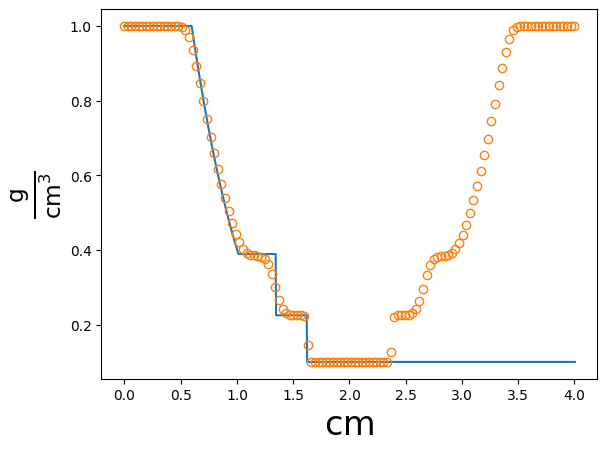

In [6]:
plt.plot(np.array(rout.mesh.boundary.in_cgs()), rho_ana)
rplot1d(rout,showfig=0,ls='none',marker='o',mfc='none', markevery=8)